# Microclimate Data Analysis

This project explores and analyzes the City of Melbourne microclimate sensor dataset.

The analysis covers data quality, preprocessing, feature scaling, environmental analysis, and potential machine learning applications.

# Part 1: Missing Values Analysis

## Problem Statement

Analyze the City of Melbourne microclimate sensor dataset and identify the number of missing values in each feature.

In [2]:
import pandas as pd

data = pd.read_csv("../07_Machine_Learning/microclimate-sensors-data.csv")

missing_values = data.isnull().sum()

print("Missing values in each feature:")

for i in missing_values.index:
    print(f"{i}: {missing_values[i]}")

Missing values in each feature:
Device_id: 0
Time: 0
SensorLocation: 0
LatLong: 0
MinimumWindDirection: 139333
AverageWindDirection: 15732
MaximumWindDirection: 139343
MinimumWindSpeed: 139343
AverageWindSpeed: 15734
GustWindSpeed: 139343
AirTemperature: 15734
RelativeHumidity: 15734
AtmosphericPressure: 15734
PM25: 78171
PM10: 78171
Noise: 78171


## Key Observation

Several sensor measurements contain missing values, particularly wind-related variables and environmental measurements such as PM25, PM10, and Noise. These missing values will need to be considered during data preprocessing.

# Part 2: Handling Missing Values

## Problem Statement

Fill in the missing entries in the dataset. For each feature containing missing values, use either the mean or median value calculated from the observed entries. Explain the reason for the choice and print the replacement value used for each feature.

In [3]:
numeric_columns= data.select_dtypes(include=['float64','int64']).columns
replacement_values = {}

for i in numeric_columns:
    if data[i].isnull().sum()>0:
        if "Direction" in i:
            replacement = data[i].median()
            reason = "Median"

        else:
            replacement = data[i].mean()
            reason = "Mean"

        replacement_values[i] = (replacement,reason)

        data[i]= data[i].fillna(replacement) #replacing missing values

print("Replacement values")
for i, value in replacement_values.items():
    print(f"{i}:{value[0]:.2f} ({value[1]})")

Replacement values
MinimumWindDirection:0.00 (Median)
AverageWindDirection:159.00 (Median)
MaximumWindDirection:351.00 (Median)
MinimumWindSpeed:0.23 (Mean)
AverageWindSpeed:0.99 (Mean)
GustWindSpeed:3.14 (Mean)
AirTemperature:16.51 (Mean)
RelativeHumidity:68.82 (Mean)
AtmosphericPressure:1014.25 (Mean)
PM25:6.83 (Mean)
PM10:9.13 (Mean)
Noise:66.36 (Mean)


## Key Observation

Missing values were replaced using the median for wind direction features and the mean for other numerical features. This approach preserves the dataset without removing a large number of observations.

# Part 3: Distribution and Correlation Analysis

## Question 3

Use histograms to examine the distribution of PM25 and PM10. Then analyse the relationship between the two variables using correlation.

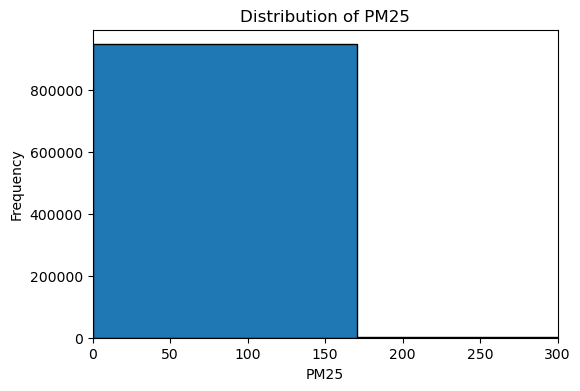

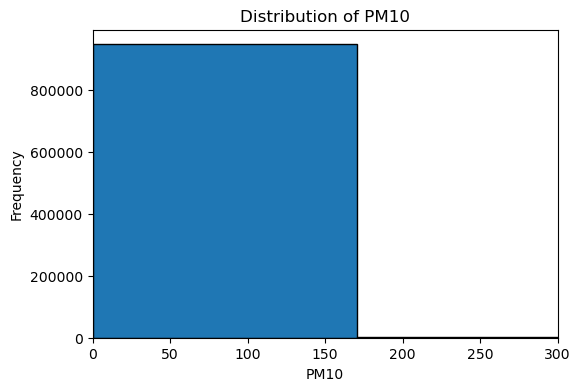

Correlation between PM25 and PM10 0.9967264209477297


In [4]:
import matplotlib.pyplot as plt 

#Histogram for PM25
plt.figure(figsize=(6,4))
plt.hist(data["PM25"], bins=20, edgecolor="black")
plt.xlim(0,300)
plt.title("Distribution of PM25")
plt.xlabel("PM25")
plt.ylabel("Frequency")
plt.show()

#Histogram for PM10
plt.figure(figsize=(6,4))
plt.hist(data["PM10"], bins=20, edgecolor="black")
plt.xlim(0,300)
plt.title("Distribution of PM10")
plt.xlabel("PM10")
plt.ylabel("Frequency")
plt.show()

correlation= data["PM25"].corr(data["PM10"])
print("Correlation between PM25 and PM10", correlation)

## Key Observation

PM25 and PM10 show a very strong positive correlation of approximately 0.997. This means that increases in PM25 levels are closely associated with increases in PM10 levels. Both variables also have most of their observations concentrated at lower values, with fewer observations at higher values.

# Part 4: Wind Direction Categorisation and Encoding

## Problem Statement

Categorise the `AverageWindDirection` feature using an appropriate data transformation and encoding approach. Display the encoded values and justify the selected transformation and encoding method.

In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def wind_direction(degree):
    if degree >=337.5 or degree <22.5:
        return "North"
    elif degree < 67.5:
        return "North-East"
    elif degree < 112.5:
        return "East"
    elif degree < 157.5:
        return "South-East"
    elif degree < 202.5:
        return "South"
    elif degree < 247.5:
        return "South-West"
    elif degree < 292.5:
        return "West"
    else:
        return "North-West"

#creating new column
data["WindDirectionCategory"] = data["AverageWindDirection"].apply(wind_direction)
#encode
encoder = LabelEncoder()
data["EncodeWindDirection"] = encoder.fit_transform(data["WindDirectionCategory"])
#display result
print(data[["AverageWindDirection","WindDirectionCategory","EncodeWindDirection"]].head(100))

    AverageWindDirection WindDirectionCategory  EncodeWindDirection
0                  200.0                 South                    4
1                  172.0                 South                    4
2                  191.0                 South                    4
3                  193.0                 South                    4
4                  192.0                 South                    4
..                   ...                   ...                  ...
95                 291.0                  West                    7
96                  35.0            North-East                    2
97                  38.0            North-East                    2
98                 324.0            North-West                    3
99                 320.0            North-West                    3

[100 rows x 3 columns]


## Key Observation

The `AverageWindDirection` feature is originally measured in degrees from 0° to 360°. To make the values easier to interpret, the continuous degree values were transformed into eight compass direction categories: North, North-East, East, South-East, South, South-West, West, and North-West.

Label Encoding was then applied to convert these categorical direction values into numerical values, making the feature suitable for further data analysis and machine learning.

# Part 5: Min-Max Scaling of Continuous Features

## Problem Statement

Apply Min-Max scaling to two continuous features, `PM25` and `PM10`. Compare and visualise the distributions of these features before and after scaling, and explain whether scaling changes their overall distribution.

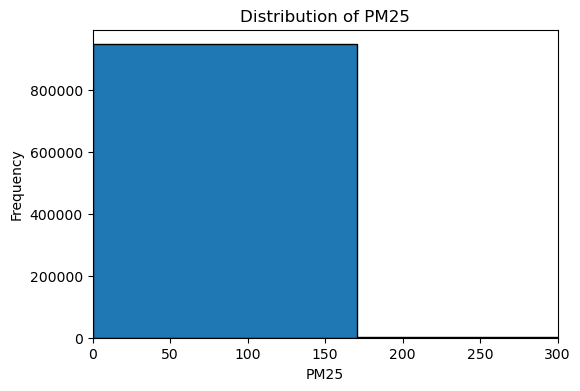

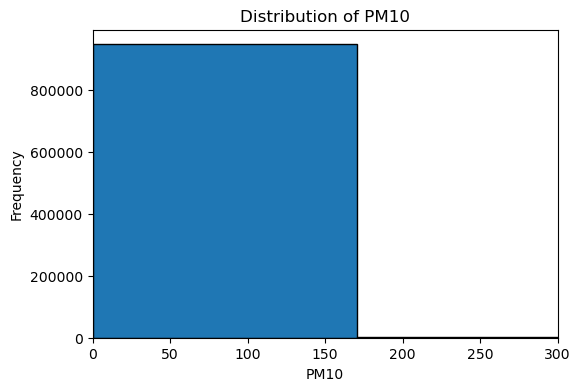

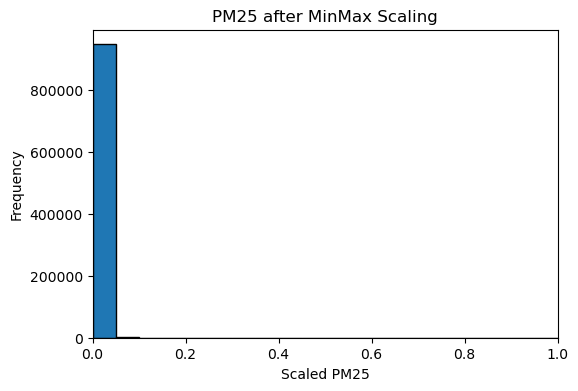

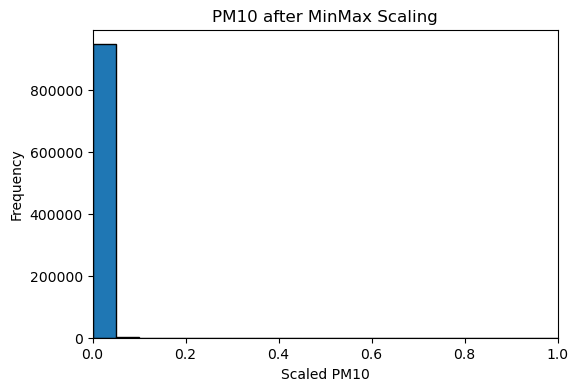

In [6]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

features = ["PM25", "PM10"] #selecting two features 

scaler= MinMaxScaler()
scaled_data = scaler.fit_transform(data[features])

scaled_df = pd.DataFrame(scaled_data, columns=["PM25_Scaled","PM10_Scaled"])

#before scaling
plt.figure(figsize=(6,4))
plt.hist(data["PM25"], bins=20, edgecolor="black")
plt.xlim(0,300)
plt.title("Distribution of PM25")
plt.xlabel("PM25")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(data["PM10"], bins=20, edgecolor="black")
plt.xlim(0,300)
plt.title("Distribution of PM10")
plt.xlabel("PM10")
plt.ylabel("Frequency")
plt.show()

#after scaling
plt.figure(figsize=(6,4))
plt.hist(scaled_df["PM25_Scaled"], bins=20, edgecolor="black")
plt.xlim(0,1)
plt.title("PM25 after MinMax Scaling")
plt.xlabel("Scaled PM25")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(scaled_df["PM10_Scaled"], bins=20, edgecolor="black")
plt.xlim(0,1)
plt.title("PM10 after MinMax Scaling")
plt.xlabel("Scaled PM10")
plt.ylabel("Frequency")
plt.show()

## Key Observation

Min-Max scaling transforms the values of `PM25` and `PM10` into a range between 0 and 1. The scaling changes the numerical scale of the features but does not change the overall shape of their distributions.

This makes the two features easier to compare and can be useful for machine learning algorithms that are sensitive to differences in feature scales.

## Question 6

For the year **2026**, which month has more wind than the rest? Explain your result.

In [9]:
# convert Time into datetime
data["Time"] = pd.to_datetime(data["Time"],utc=True)

#finding average speed for each month in the year 2026
wind= data[data["Time"].dt.year==2026].groupby(
    data["Time"].dt.month_name()
)["AverageWindSpeed"].mean()

print("Month with highest wind speed:",wind.idxmax())
print(wind.max())


Month with highest wind speed: January
1.135841801421611


## Key Observation

The dataset was filtered to include records from the year 2026, and the average wind speed was calculated for each month. January had the highest average wind speed, with a value of approximately **1.14**. Therefore, January was identified as the month with the strongest average wind conditions in 2026.